In [27]:
# Librerías 

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [35]:
#cargar imagen 
ruta = r"C:\Users\irwin\Downloads\Monedas.jpeg"

imagen = cv2.imread(ruta)

if imagen is None:
    print("No se pudo cargar la imagen")
else:
    print("Imagen cargada correctamente")

Imagen cargada correctamente


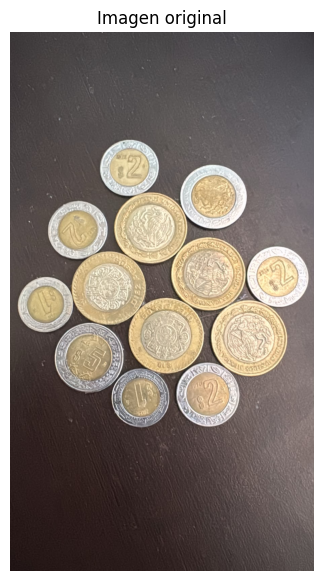

In [34]:
# Convertir la imagen de BGR a RGB para mostrarla correctamente con Matplotlib

imagen_rgb = cv2.cvtColor(
    imagen,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 7))

plt.imshow(imagen_rgb)

plt.title("Imagen original")

plt.axis("off")

plt.show()

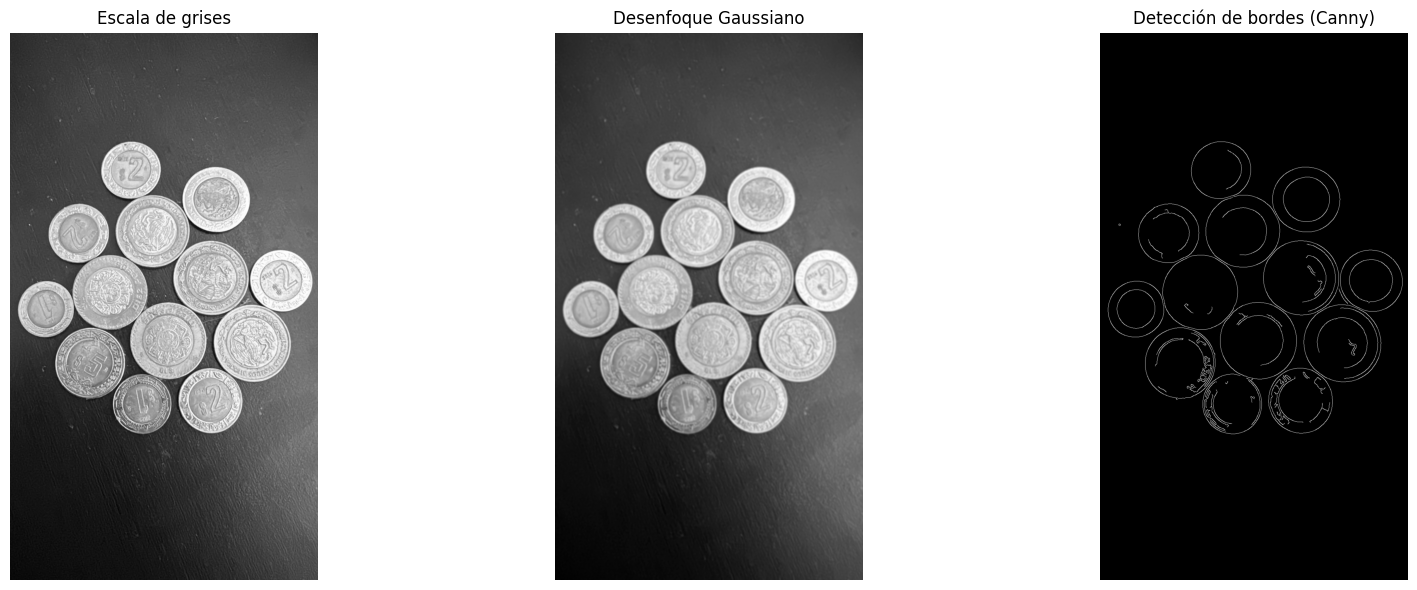

In [ ]:
# Convertir la imagen a escala 

# CONVERTIR A ESCALA DE GRISES

gris = cv2.cvtColor(
    imagen,
    cv2.COLOR_BGR2GRAY
)

# DESENFOQUE GAUSSIANO

gauss = cv2.GaussianBlur(
    gris,
    (9, 9),
    2
)

# DETECCIÓN DE BORDES (CANNY)

bordes = cv2.Canny(
    gauss,
    threshold1=50,
    threshold2=150
)

# MOSTRAR RESULTADOS

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(gris, cmap="gray")
plt.title("Escala de grises")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gauss, cmap="gray")
plt.title("Desenfoque Gaussiano")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(bordes, cmap="gray")
plt.title("Detección de bordes (Canny)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
# Detectar círculos usando la Transformada de Hough

circulos = cv2.HoughCircles(
    gris_suavizado,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,
    param1=120,
    param2=55,
    minRadius=25,
    maxRadius=75
)

In [32]:
# Dibujar los círculos detectados en la imagen original

resultado = imagen.copy()

if circulos is not None:

    circulos = np.round(
        circulos[0, :]
    ).astype("int")

    for x, y, radio in circulos:

        # Dibujar círculo
        cv2.circle(
            resultado,
            (x, y),
            radio,
            (0, 255, 0),
            3
        )

        # Dibujar centro
        cv2.circle(
            resultado,
            (x, y),
            5,
            (0, 0, 255),
            -1
        )

        # Mostrar coordenadas
        cv2.putText(
            resultado,
            f"({x},{y})",
            (x + 10, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

else:

    print(
        "No se detectaron círculos"
    )

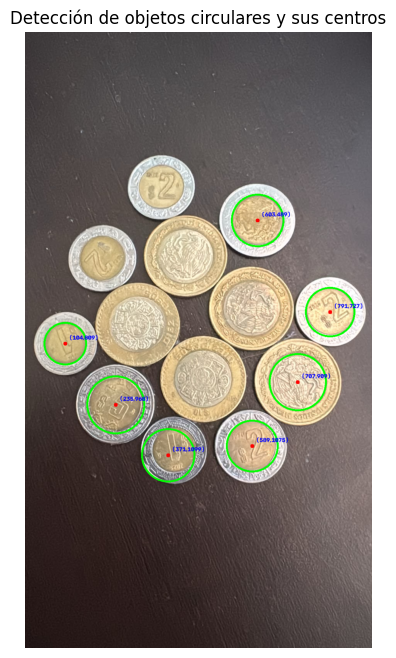

In [ ]:
# Mostrar resultado

resultado_rgb = cv2.cvtColor(
    resultado,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))

plt.imshow(resultado_rgb)

plt.title(
    "Detección de objetos circulares y sus centros"
)

plt.axis("off")

plt.show()

In [33]:
# Mostrar información sobre los círculos detectados

if circulos is not None:

    print(
        "Número de círculos detectados:",
        len(circulos)
    )

    print()

    for i, (x, y, radio) in enumerate(
        circulos,
        start=1
    ):

        print(
            f"Círculo {i}: "
            f"Centro = ({x}, {y}), "
            f"Radio = {radio}"
        )

Número de círculos detectados: 7

Círculo 1: Centro = (603, 489), Radio = 67
Círculo 2: Centro = (791, 727), Radio = 63
Círculo 3: Centro = (707, 909), Radio = 73
Círculo 4: Centro = (589, 1075), Radio = 66
Círculo 5: Centro = (104, 809), Radio = 54
Círculo 6: Centro = (235, 968), Radio = 74
Círculo 7: Centro = (371, 1099), Radio = 68


In [ ]:
# Crear una tabla con la información de los círculos detectados

resultados = []

if circulos is not None:

    for i, (x, y, radio) in enumerate(
        circulos,
        start=1
    ):

        resultados.append({
            "Objeto": i,
            "Centro_X": x,
            "Centro_Y": y,
            "Radio": radio
        })

df_circulos = pd.DataFrame(
    resultados
)

df_circulos

,Objeto,Centro_X,Centro_Y,Radio
0,1,603,489,67
1,2,791,727,63
2,3,707,909,73
3,4,589,1075,66
4,5,104,809,54
5,6,235,968,74
6,7,371,1099,68
